In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
import umap
from sklearn.cluster import MiniBatchKMeans

from pathlib import Path

/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
ROOT = Path.cwd().parent

In [5]:
style_path = ( ROOT 
              / 'notebooks' 
              / 'styler.mplstyle'
              )
plt.style.use(style_path)

In [6]:

data_path = (
    ROOT
    / "data"
    / "gold"
    / "model=nvidia-llama-nemotron-embed-vl-1b-v2"
    / "source=gdelt"
    / "embeddings.parquet"
)

df = pd.read_parquet(data_path)

In [11]:
df['published_at'].head(14)

0     2024-12-01T00:00:00+00:00
1     2024-12-01T00:00:00+00:00
2     2024-12-01T00:15:00+00:00
3     2024-12-01T00:15:00+00:00
4     2024-12-01T00:15:00+00:00
5     2024-12-01T00:15:00+00:00
6     2024-12-01T00:30:00+00:00
7     2024-12-01T00:30:00+00:00
8     2024-12-01T00:30:00+00:00
9     2024-12-01T00:30:00+00:00
10    2024-12-01T00:45:00+00:00
11    2024-12-01T00:45:00+00:00
12    2024-12-01T00:45:00+00:00
13    2024-12-01T01:00:00+00:00
Name: published_at, dtype: object

### Pre Proccessing

In [12]:
embedding_col = "embedding"

X = np.vstack(df[embedding_col].to_numpy())

In [13]:
X

array([[ 0.01367188, -0.00473022,  0.0324707 , ...,  0.01531982,
        -0.03039551, -0.01953125],
       [ 0.0055542 ,  0.02844238,  0.00102234, ...,  0.02441406,
        -0.00466919,  0.00376892],
       [ 0.0055542 ,  0.02844238,  0.00102234, ...,  0.02441406,
        -0.00466919,  0.00376892],
       ...,
       [ 0.00357056, -0.00070953, -0.01647949, ..., -0.02172852,
        -0.00411987, -0.05029297],
       [ 0.04443359, -0.02001953, -0.00343323, ..., -0.01635742,
         0.00372314, -0.01153564],
       [-0.01055908, -0.00140381, -0.00263977, ..., -0.00744629,
         0.01098633,  0.00643921]], shape=(19599, 2048))

In [14]:
print(len(X[0]))

2048


### PCA Projection

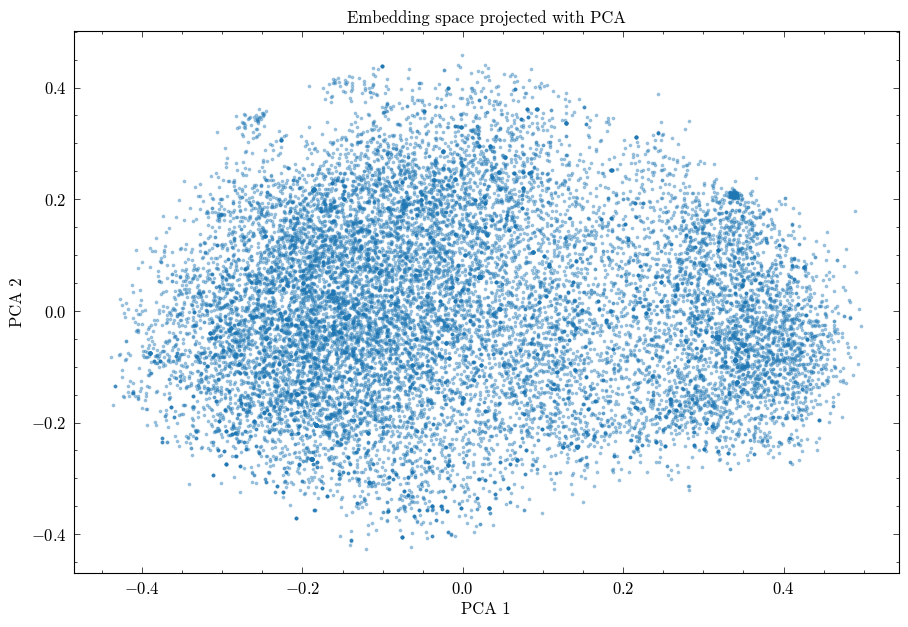

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

df["pca_x"] = coords[:, 0]
df["pca_y"] = coords[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(
    df["pca_x"],
    df["pca_y"],
    s=3,
    alpha=0.35
)
plt.title("Embedding space projected with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### U Map Projection

In [16]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

coords = reducer.fit_transform(X)

df["umap_x"] = coords[:, 0]
df["umap_y"] = coords[:, 1]

/home/jackyeung99/eml_transformer/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Clustering

In [ ]:

inertias = []

for k in range(2, 50):
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X)
    inertias.append(km.inertia_)


In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(range(2, 50), inertias)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = MiniBatchKMeans(
    n_clusters=12,
    random_state=42,
    batch_size=4096
)

df["cluster"] = kmeans.fit_predict(X)

In [ ]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    plt.scatter(
        subset["pca_x"],
        subset["pca_y"],
        s=3,
        alpha=0.35,
        label=str(cluster_id)
    )

plt.title("Embedding clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(markerscale=4, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
cluster_counts = (
        df["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="count")
    )

plt.figure(figsize=(10, 5))
plt.bar(cluster_counts["cluster"].astype(str), cluster_counts["count"])
plt.title("Embedding cluster sizes")
plt.xlabel("Cluster")
plt.ylabel("Record count")
plt.show()

### Interactive Clustering

In [ ]:
df.columns

In [ ]:
for idx, metadata in df["metadata"].items():
    if (
        isinstance(metadata, dict)
        and metadata.get("key_messages")
    ):
        print(f"Index: {idx}")
        from pprint import pprint
        pprint(metadata)
        break

In [ ]:
import html
import textwrap
import plotly.express as px

plot_df = df.copy()

# Optional: keep only rows with usable key messages
# plot_df = plot_df[
#     plot_df["metadata"].apply(
#         lambda m: (
#             isinstance(m, dict)
#             and m.get("key_messages") is not None
#             and str(m.get("key_messages")).strip()
#             and str(m.get("key_messages")).lower() != "none"
#         )
#     )
# ].copy()

def format_key_messages(metadata, max_lines=6, width=80):
    if not isinstance(metadata, dict):
        return "No key messages found"

    key_messages = metadata.get("key_messages", "")

    if isinstance(key_messages, list):
        text = "\n".join(str(msg) for msg in key_messages)
    else:
        text = str(key_messages)

    lines = [line.strip() for line in text.splitlines() if line.strip()]

    if not lines:
        return "No key messages found"

    wrapped_lines = []
    for line in lines[:max_lines]:
        safe_line = html.escape(line)
        wrapped_lines.extend(textwrap.wrap(safe_line, width=width))

    return "<br>".join(wrapped_lines)

def build_hover(row):
    title = html.escape(str(row.get("title", "")))
    key_messages = format_key_messages(row.get("metadata", {}))
    cluster = html.escape(str(row.get("cluster", "")))

    return (
        f"<b>{title}</b>"
        f"<br><br><b>Cluster:</b> {cluster}"
        f"<br><br>{key_messages}"
    )

plot_df["hover"] = plot_df.apply(build_hover, axis=1)

def make_embedding_plot(plot_df, x_col, y_col, title, x_label, y_label):
    fig = px.scatter(
        plot_df,
        x=x_col,
        y=y_col,
        color=plot_df["cluster"].astype(str),
        template="plotly_white",
        opacity=0.5,
    )

    fig.update_traces(
        marker=dict(size=5),
        customdata=plot_df["hover"],
        hovertemplate="%{customdata}<extra></extra>",
    )

    fig.update_layout(
        title=title,
        xaxis_title=x_label,
        yaxis_title=y_label,
        legend_title="Cluster",
        width=1100,
        height=750,
        hoverlabel=dict(
            bgcolor="white",
            font_size=13,
            font_family="Arial",
            align="left",
        ),
    )

    return fig

In [ ]:
fig_pca = make_embedding_plot(
    plot_df=plot_df,
    x_col="pca_x",
    y_col="pca_y",
    title="Embedding PCA Projection by Cluster",
    x_label="PCA 1",
    y_label="PCA 2",
)

# fig_pca.show()

In [ ]:
fig_umap = make_embedding_plot(
    plot_df=plot_df,
    x_col="umap_x",
    y_col="umap_y",
    title="Embedding UMAP Projection by Cluster",
    x_label="UMAP 1",
    y_label="UMAP 2",
)

# fig_umap.show()

In [ ]:
# fig_pca.write_html("embedding_pca_clusters.html")
# fig_umap.write_html("embedding_umap_clusters.html")

### cluster text

In [ ]:
import html
import textwrap
from IPython.display import HTML, display

def extract_key_messages(metadata):
    if not isinstance(metadata, dict):
        return None

    msgs = metadata.get("key_messages")

    if msgs is None:
        return None

    if isinstance(msgs, list):
        msgs = "\n".join(str(m) for m in msgs)

    msgs = str(msgs).strip()

    if not msgs or msgs.lower() == "none":
        return None

    return msgs

def wrap_text(text, width=100):
    return "<br>".join(
        textwrap.wrap(html.escape(str(text)), width=width)
    )

def show_cluster_key_messages(df, n_examples=5):
    rows = []

    for cluster_id, group in df.groupby("cluster"):
        examples = (
            group.assign(
                key_message=group["metadata"].apply(extract_key_messages)
            )
            .dropna(subset=["key_message"])
        )

        examples = examples.sample(
            n=min(20, len(examples)),
            random_state=42
        )

        examples = examples.head(n_examples)

        if examples.empty:
            continue

        cards = ""

        for _, row in examples.iterrows():
            title = wrap_text(row.get("title", ""), width=90)
            msg = wrap_text(row["key_message"], width=110)

            cards += f"""
            <div style="
                border-left: 4px solid #444;
                background: #fafafa;
                padding: 10px 14px;
                margin: 8px 0;
                border-radius: 6px;
            ">
                <div style="font-weight: 600; margin-bottom: 6px;">
                    {title}
                </div>
                <div style="font-size: 13px; line-height: 1.45;">
                    {msg}
                </div>
            </div>
            """

        rows.append(f"""
        <div style="
            border: 1px solid #ddd;
            padding: 16px;
            margin: 16px 0;
            border-radius: 10px;
            background: white;
        ">
            <h3 style="margin-top: 0;">Cluster {cluster_id}</h3>
            <p><b>Documents:</b> {len(group):,}</p>
            {cards}
        </div>
        """)

    display(HTML("".join(rows)))

# show_cluster_key_messages(df, n_examples=5)